In [1]:
pip install autoviml

  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/44.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.1 MB 621.2 kB/s eta 0:01:11
    --------------------------------------- 0.8/44.1 MB 684.4 kB/s eta 0:01:04
    --------------------------------------- 0.8/44.1 MB 684.4 kB/s eta 0:01:04
    --------------------------------------- 1.0/44.1 MB 689.2 kB/s eta 0:01:03
   - -------------------------------------- 1.3/44.1 MB 762.6 kB/s eta 0:00:57
   - -------------------------------------- 1.3/44.1 MB 762.6 kB/s eta 0:00:57
   - -------------------------------------- 1

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.2 requires nltk<3.9,>=3.4.5, but you have nltk 3.9.1 which is incompatible.
bluecast 1.6.4 requires dill<0.4.0,>=0.3.3, but you have dill 0.4.0 which is incompatible.
mediapipe 0.10.21 requires protobuf<5,>=4.25.3, but you have protobuf 5.29.4 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


##############  D A T A   S E T  A N A L Y S I S  #######################
Training Set Shape = (120, 5)
    Training Set Memory Usage = 0.01 MB
Test Set Shape = (30, 4)
    Test Set Memory Usage = 0.00 MB
Single_Label Target: ['target']

################ Multi_Classification VISUALIZATION Started #####################
Random shuffling the data set before training
    Using RandomizedSearchCV for Hyper Parameter Tuning. This is 3X faster than GridSearchCV...
ALERT! Setting Imbalanced_Flag to True in Auto_ViML for Multi_Classification problems improves results!
       Class  -> Counts -> Percent
           0:      40  ->   33.3%
           1:      40  ->   33.3%
           2:      40  ->   33.3%
    Target target is already numeric. No transformation done.
Alert! Rare Class is not 1 but 0 in this data set
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#########

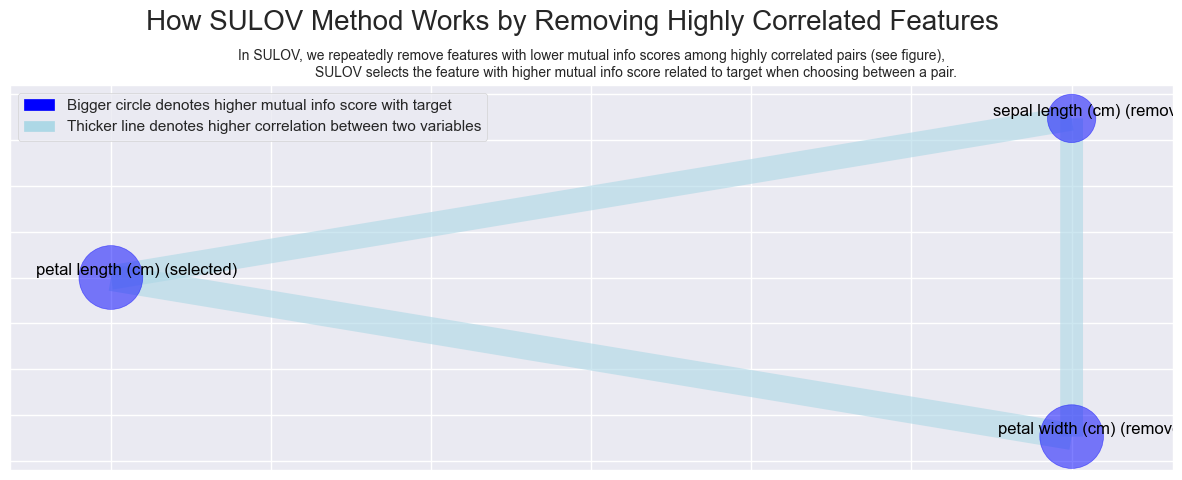

Splitting selected features into float and categorical (integer) variables:
    (2) float variables ...
    (0) categorical vars...
###############################################################################
#######     F E A T U R E   S E L E C T I O N    BY   X G B O O S T    ########
###############################################################################
Current number of predictors = 2 
    Finding Important Features using Boosted Trees algorithm...
        using 2 variables...
Found 2 important features
    Performing limited feature engineering for binning, add_poly and KMeans_Featurizer flags  ...
    Train CV Split completed with TRAIN rows =  108 , CV rows =  12
    Binning_Flag set to False or there are no float vars in data set to be binned
    KMeans_Featurizer set to False or there are no float variables in data
Performing MinMax scaling of train and validation data
#################################################################################
######## Linea

TypeError: AdaBoostClassifier.__init__() got an unexpected keyword argument 'base_estimator'

<Figure size 1500x750 with 0 Axes>

In [4]:
from autoviml.Auto_ViML import Auto_ViML
from sklearn.datasets import load_iris
import pandas as pd

# Load the Iris dataset and prepare as a DataFrame
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# Combine features and target into one DataFrame (AutoVIML expects this)
df = X.copy()
df['target'] = y

# Split the data into train and test sets manually (optional)
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['target'])

# Separate target for train and test
target = 'target'

# Initialize and run AutoVIML
model, features = Auto_ViML(
    train=train_df,
    target=target,
    test=test_df.drop(columns=[target]),  # test data without target column
    verbose=1
)

# Predict on test set
test_preds = model.predict(test_df.drop(columns=[target]))

# Evaluate accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test_df[target], test_preds)
print(f"Test Accuracy: {accuracy:.4f}")